In [ ]:
#importing the libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Loading the Dataset
df = pd.read_csv("C:/Users/temp.admin/Documents/Stats AIDS/diabetes.csv")
df.head

<bound method NDFrame.head of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50 

In [3]:
#selecting the numerical values
glucose = df["Glucose"]

print("Mean Glucose:", glucose.mean())

Mean Glucose: 120.89453125


In [ ]:
#Bootstrap Samples
np.random.seed(42)

n = len(glucose)
bootstrap_means = []

for i in range(1000):
    sample = glucose.sample(n=n, replace=True)
    bootstrap_means.append(sample.mean())

print("Number of bootstrap samples:", len(bootstrap_means))

Number of bootstrap samples: 1000


In [5]:
#Calculating Mean for every Bootstrap sample
print("First 10 Bootstrap Means:")
print(bootstrap_means[:10])

First 10 Bootstrap Means:
[121.35286458333333, 122.08463541666667, 121.85677083333333, 121.45052083333333, 120.92708333333333, 119.99609375, 120.1328125, 120.26953125, 119.65625, 121.02213541666667]


In [6]:
#Bootstrap Confidence Interval
lower = np.percentile(bootstrap_means, 2.5)
upper = np.percentile(bootstrap_means, 97.5)

print("95% Bootstrap Confidence Interval")
print("Lower Limit:", lower)
print("Upper Limit:", upper)

95% Bootstrap Confidence Interval
Lower Limit: 118.77721354166667
Upper Limit: 123.01858723958334


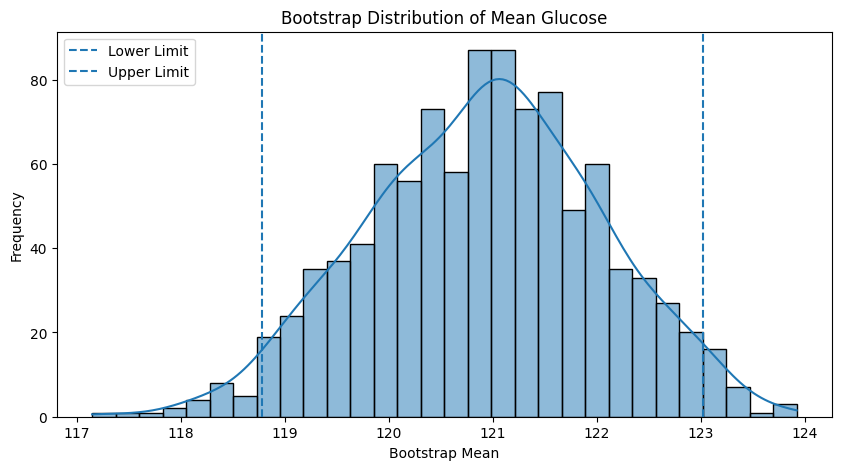

In [7]:
#visulizing Bootstrap Distribution
plt.figure(figsize=(10, 5))

sns.histplot(bootstrap_means, bins=30, kde=True)

plt.axvline(lower, linestyle="--", label="Lower Limit")
plt.axvline(upper, linestyle="--", label="Upper Limit")

plt.title("Bootstrap Distribution of Mean Glucose")
plt.xlabel("Bootstrap Mean")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [8]:
#Divide Data into groups
group0 = df[df["Outcome"] == 0]["Glucose"]
group1 = df[df["Outcome"] == 1]["Glucose"]

print("Non-diabetic patients:", len(group0))
print("Diabetic patients:", len(group1))

Non-diabetic patients: 500
Diabetic patients: 268


In [9]:
#Calcultae Observed Difference Between Group Means
mean0 = group0.mean()
mean1 = group1.mean()

observed_difference = mean1 - mean0

print("Mean Glucose - Non-diabetic:", mean0)
print("Mean Glucose - Diabetic:", mean1)
print("Observed Difference:", observed_difference)

Mean Glucose - Non-diabetic: 109.98
Mean Glucose - Diabetic: 141.25746268656715
Observed Difference: 31.277462686567148


In [10]:
# Randomly Permute Group Labels
np.random.seed(42)

combined = pd.concat([group0, group1]).reset_index(drop=True)
n0 = len(group0)
permutation_differences = []
for i in range(1000):
    shuffled = np.random.permutation(combined)
    new_group0 = shuffled[:n0]
    new_group1 = shuffled[n0:]
    difference = new_group1.mean() - new_group0.mean()
    permutation_differences.append(difference)

print("Number of permutations:", len(permutation_differences))

Number of permutations: 1000


In [11]:
#Calculate Diffrence for every Permutation
print("First 10 Permutation Differences:")
print(permutation_differences[:10])

First 10 Permutation Differences:
[4.013462686567166, 0.3454029850746281, -0.8581791044776139, 1.7897014925373185, -1.408388059701494, 2.752567164179112, -1.2421791044776143, 2.9187761194029775, -2.141999999999996, 0.2995522388059584]


In [12]:
#Compare Observed Difference with Permutation Distribution
permutation_differences = np.array(permutation_differences)

p_value = np.mean(
    np.abs(permutation_differences) >= abs(observed_difference)
)

print("Observed Difference:", observed_difference)
print("Permutation Test P-value:", p_value)

Observed Difference: 31.277462686567148
Permutation Test P-value: 0.0


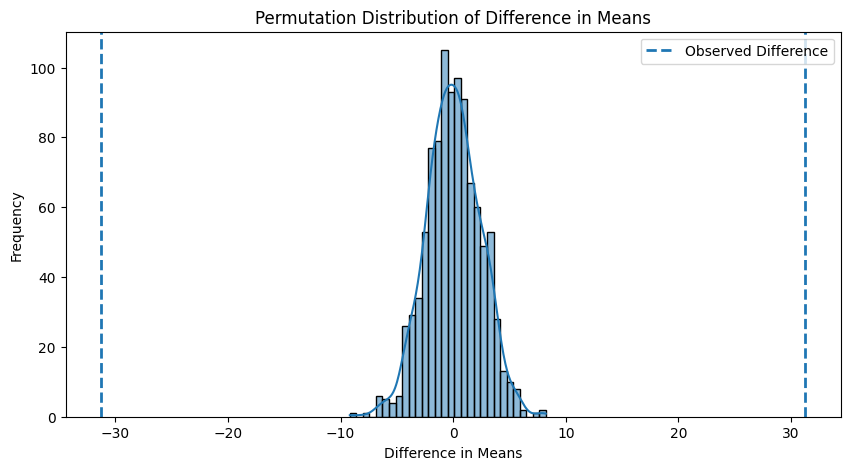

In [13]:
#Visulize the Permutation Distribution
plt.figure(figsize=(10, 5))

sns.histplot(permutation_differences, bins=30, kde=True)

plt.axvline(
    observed_difference,
    linestyle="--",
    linewidth=2,
    label="Observed Difference"
)

plt.axvline(
    -observed_difference,
    linestyle="--",
    linewidth=2
)

plt.title("Permutation Distribution of Difference in Means")
plt.xlabel("Difference in Means")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [14]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis
